# Demo y Validación del paquete `traficFines`

Este cuaderno muestra el uso completo de las clases `Cache`, `CacheUrl` y `MadridFines`,
así como la función `get_url`, e ilustra el comportamiento ante situaciones de error.

In [1]:
# Si el paquete no está instalado, añadimos la carpeta raíz del proyecto al path
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('.').resolve().parent))

from traficFines import Cache, CacheUrl, CacheError, MadridFines, MadridError, get_url
print("Paquete importado correctamente.")

Paquete importado correctamente.


## 1. Módulo `cache` — Clase `Cache`

In [2]:
import tempfile, pathlib

tmpdir = pathlib.Path(tempfile.mkdtemp())
cache = Cache(app_name="demo_app", base_dir=tmpdir, obsolescence=7)
print(f"Directorio de caché: {cache.cache_dir}")
print(f"App name: {cache.app_name}")
print(f"Obsolescencia: {cache.obsolescence} días")

Directorio de caché: /tmp/tmpe6a3sxpo/demo_app
App name: demo_app
Obsolescencia: 7 días


In [3]:
# set() y load()
cache.set("clave1", "Hola desde la caché")
print(f"exists('clave1'): {cache.exists('clave1')}")
print(f"load('clave1'): {cache.load('clave1')}")
print(f"how_old('clave1'): {cache.how_old('clave1'):.2f} ms")

exists('clave1'): True
load('clave1'): Hola desde la caché
how_old('clave1'): 2.12 ms


In [4]:
# delete() y clear()
cache.set("borrar_me", "dato temporal")
cache.delete("borrar_me")
print(f"exists('borrar_me') tras delete: {cache.exists('borrar_me')}")

cache.set("a", "1"); cache.set("b", "2")
cache.clear()
print(f"exists('a') tras clear: {cache.exists('a')}")
print(f"exists('b') tras clear: {cache.exists('b')}")

exists('borrar_me') tras delete: False
exists('a') tras clear: False
exists('b') tras clear: False


In [5]:
# Error al cargar clave inexistente
try:
    cache.load("no_existe")
except CacheError as e:
    print(f"CacheError capturado: {e}")

CacheError capturado: El elemento 'no_existe' no existe en la caché.


In [6]:
# Atributos de solo lectura
try:
    cache.app_name = "otro"
except AttributeError as e:
    print(f"AttributeError capturado (solo lectura): {e}")

AttributeError capturado (solo lectura): property 'app_name' of 'Cache' object has no setter


## 2. Módulo `cache` — Clase `CacheUrl`

In [7]:
cache_url = CacheUrl(app_name="demo_urls", base_dir=tmpdir, obsolescence=1)

# Probar con una URL pública pequeña
url_test = "https://httpbin.org/get"
contenido = cache_url.get(url_test)
print(f"Descarga exitosa. Longitud del contenido: {len(contenido)} caracteres")
print(f"exists(url): {cache_url.exists(url_test)}")
print(f"how_old(url): {cache_url.how_old(url_test):.2f} ms")

Descarga exitosa. Longitud del contenido: 308 caracteres
exists(url): True
how_old(url): 5.22 ms


In [8]:
# Segunda llamada: usa caché (no descarga de nuevo)
contenido2 = cache_url.get(url_test)
print(f"Contenido idéntico en segunda llamada: {contenido == contenido2}")

Contenido idéntico en segunda llamada: True


In [9]:
# Error ante URL inválida
try:
    cache_url.get("https://url.que.no.existe.xyz/datos.csv")
except CacheError as e:
    print(f"CacheError capturado: {e}")

CacheError capturado: Error al descargar 'https://url.que.no.existe.xyz/datos.csv': HTTPSConnectionPool(host='url.que.no.existe.xyz', port=443): Max retries exceeded with url: /datos.csv (Caused by NameResolutionError("HTTPSConnection(host='url.que.no.existe.xyz', port=443): Failed to resolve 'url.que.no.existe.xyz' ([Errno -2] Name or service not known)"))


## 3. Módulo `madridFines` — Función `get_url`

In [10]:
# Obtener URL para diciembre 2024
url_dic24 = get_url(2024, 12)
print(f"URL diciembre 2024: {url_dic24}")


URL diciembre 2024: https://datos.madrid.es/dataset/210104-0-multas-circulacion-detalle/resource/210104-15-multas-circulacion-detalle-csv/download/210104-15-multas-circulacion-detalle-csv.csv


In [11]:
# Error con mes inválido
try:
    get_url(2024, 13)
except MadridError as e:
    print(f"MadridError mes inválido: {e}")

# Error con año anterior a 2017
try:
    get_url(2015, 1)
except MadridError as e:
    print(f"MadridError año anterior a 2017: {e}")

MadridError mes inválido: Mes no válido: 13. Debe estar entre 1 y 12.
MadridError año anterior a 2017: Año 2015 anterior a 2017; sin datos disponibles.


## 4. Clase `MadridFines` — Uso completo

In [12]:
mf = MadridFines(app_name="demo_multas", obsolescence=7)
print(f"data vacío inicialmente: {mf.data.empty}")
print(f"loaded inicialmente: {mf.loaded}")

data vacío inicialmente: True
loaded inicialmente: []


In [13]:
# Cargar diciembre 2024
mf.add(2024, 12)
print(f"Meses cargados: {mf.loaded}")
print(f"Total filas: {len(mf.data)}")
mf.data.head(3)


Meses cargados: [(12, 2024)]
Total filas: 249801


,CALIFICACION,LUGAR,MES,ANIO,HORA,IMP_BOL,DESCUENTO,PUNTOS,DENUNCIANTE,HECHO_BOL,VEL_LIMITE,VEL_CIRCULA,COORDENADA_X,COORDENADA_Y
fecha,,,,,,,,,,,,,,
2024-12-01 20:23:00,LEVE,CL CLARA DEL REY 36,12,2024,20.23,60.0,SI,0,SER,ESTACIONAR CON AUTORIZACI�N NO V�LIDA.,NaN,NaN,NaN,NaN
2024-12-01 20:27:00,LEVE,CL CLARA DEL REY 28,12,2024,20.27,90.0,SI,0,SER,"ESTACIONAR, SIN LA CORRESPONDIENTE AUTORIZACI�...",NaN,NaN,NaN,NaN
2024-12-01 20:45:00,GRAVE,CL CANILLAS 63,12,2024,20.45,200.0,SI,0,SER,ESTACIONAR OBSTACULIZANDO LA UTILIZACI�N DE UN...,NaN,NaN,NaN,NaN


In [14]:
# add() no duplica meses ya cargados
filas_antes = len(mf.data)
mf.add(2024, 12)
print(f"Filas antes: {filas_antes}, filas después: {len(mf.data)} (deben ser iguales)")




Filas antes: 249801, filas después: 249801 (deben ser iguales)


In [15]:
# Cargar un mes adicional (noviembre 2024)
mf.add(2024, 11)
print(f"Meses cargados tras añadir noviembre: {mf.loaded}")
print(f"Total filas ahora: {len(mf.data)}")


Meses cargados tras añadir noviembre: [(12, 2024), (11, 2024)]
Total filas ahora: 503914


In [16]:
# fines_calification()
cal = mf.fines_calification()
print("Distribución de multas por calificación:")
cal

Distribución de multas por calificación:


,CALIFICACION,GRAVE,LEVE,MUY GRAVE
MES,ANIO,,,
11,2024,156519,96829,765
12,2024,157605,91388,808


In [17]:
# total_payment()
pago = mf.total_payment()
print("Resumen de importes:")
pago

Resumen de importes:


,,importe_maximo,importe_minimo
MES,ANIO,,
11,2024,36762060.0,18381030.0
12,2024,37005230.0,18502615.0


Gráfico guardado como evolucion_multas.png


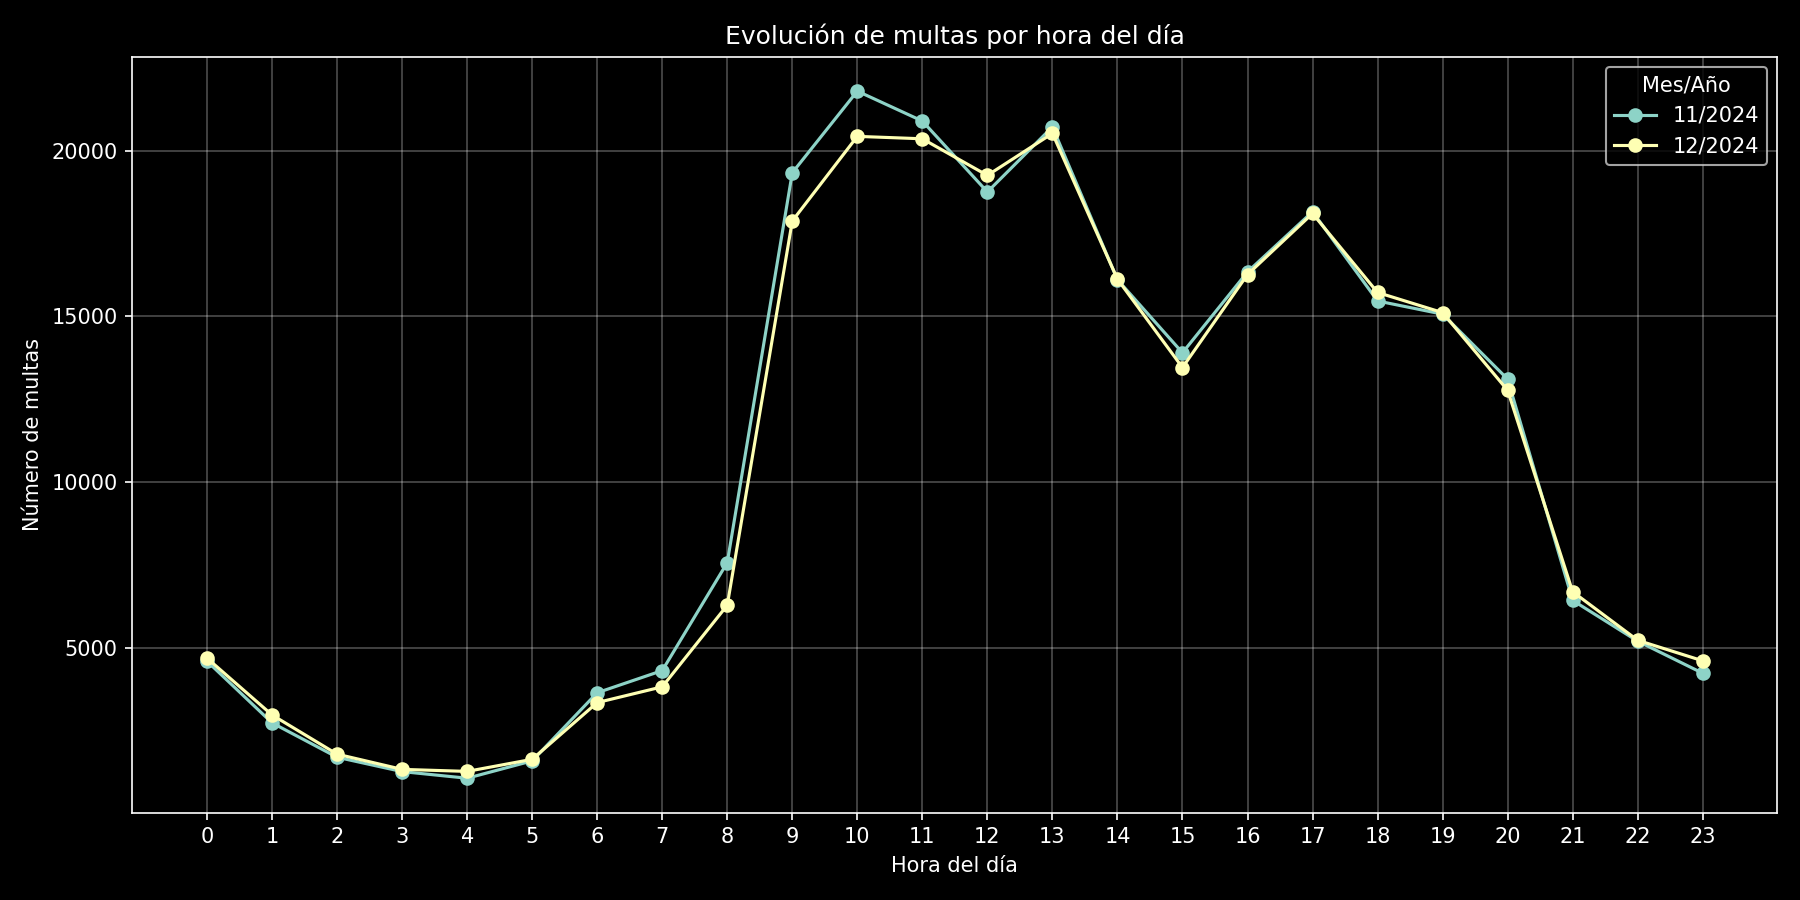

In [18]:
# fines_hour()
mf.fines_hour("evolucion_multas.png")
print("Gráfico guardado como evolucion_multas.png")

from IPython.display import Image
Image("evolucion_multas.png")

In [19]:
# Errores al acceder a métodos sin datos
mf_vacio = MadridFines()
for metodo_nombre, metodo in [
    ('fines_calification', mf_vacio.fines_calification),
    ('total_payment',      mf_vacio.total_payment),
]:
    try:
        metodo()
    except MadridError as e:
        print(f"MadridError en {metodo_nombre}(): {e}")

try:
    mf_vacio.fines_hour("test.png")
except MadridError as e:
    print(f"MadridError en fines_hour(): {e}")

MadridError en fines_calification(): No hay datos cargados. Usa add() primero.
MadridError en total_payment(): No hay datos cargados. Usa add() primero.
MadridError en fines_hour(): No hay datos cargados. Usa add() primero.


In [20]:
# Propiedades de solo lectura
try:
    mf.data = None
except AttributeError as e:
    print(f"AttributeError data: {e}")

try:
    mf.loaded = []
except AttributeError as e:
    print(f"AttributeError loaded: {e}")

AttributeError data: property 'data' of 'MadridFines' object has no setter
AttributeError loaded: property 'loaded' of 'MadridFines' object has no setter
